## Real Analytical Kernel, Complex calculated kernel, Looking only at real part of prediction, train data from -pi/2 to pi/2

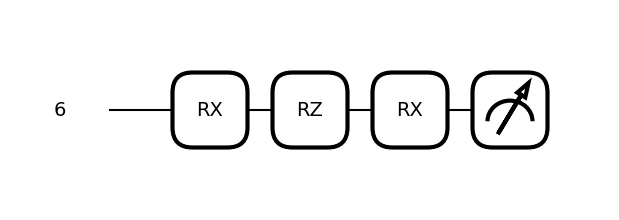

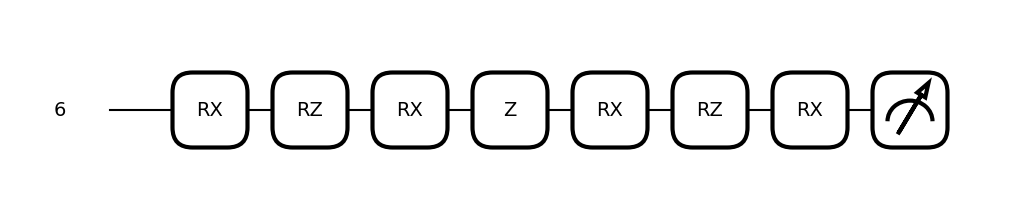

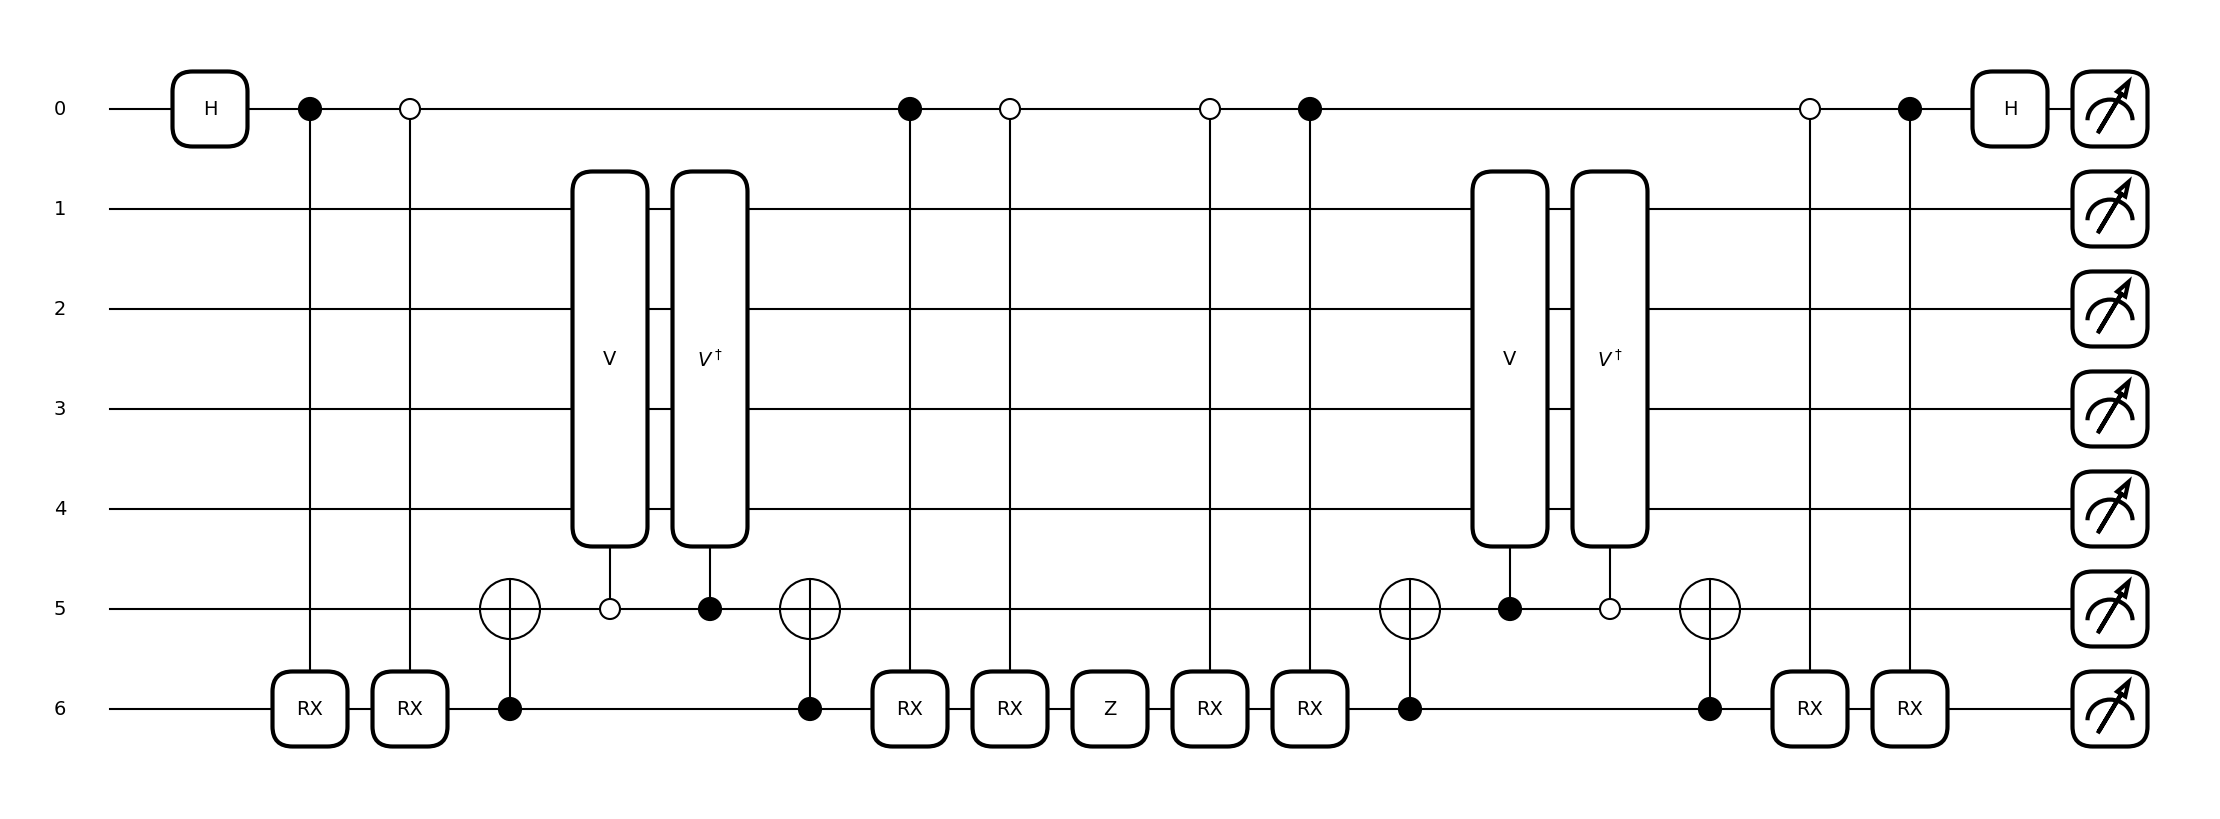

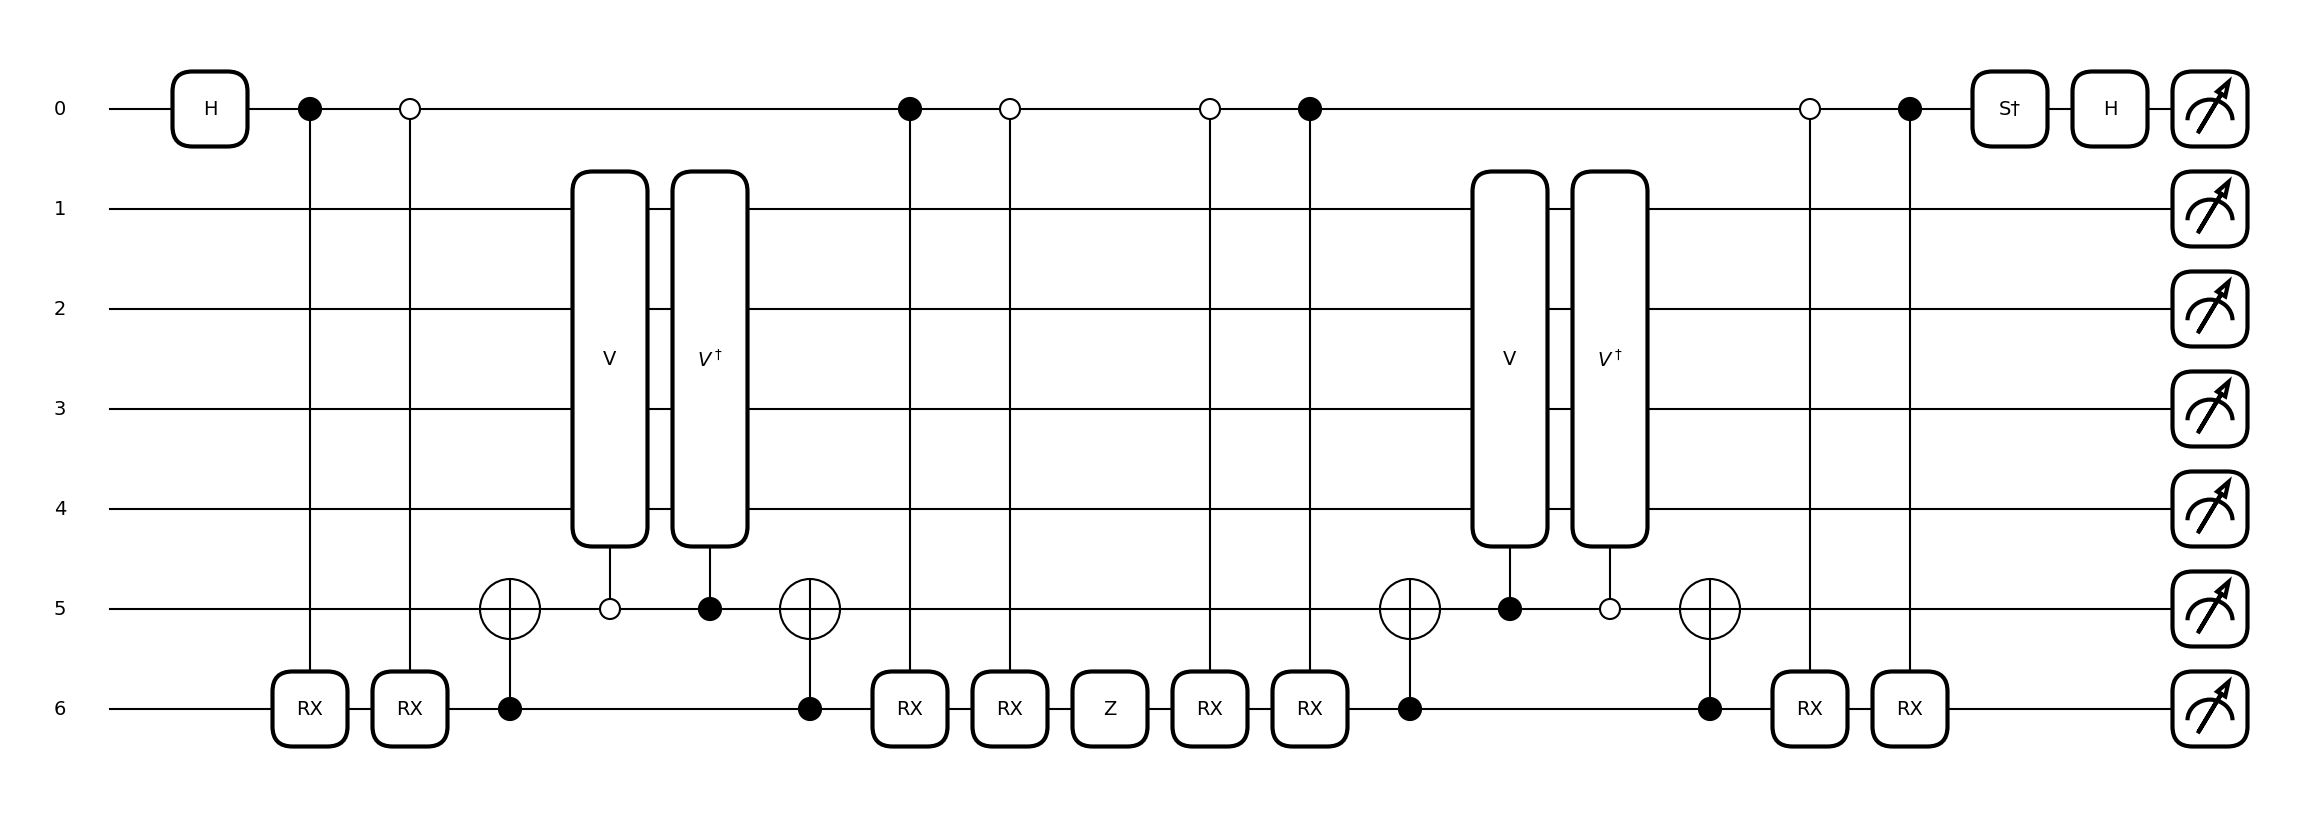

c:\Users\rjuya\anaconda3\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Running seeds (parallel):   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

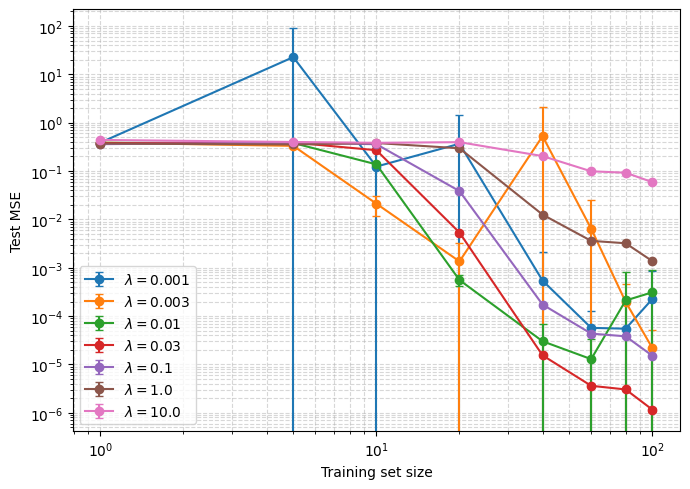

In [1]:
import pennylane as qml
import numpy as np


from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score
import pickle
from pathlib import Path


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    # name = "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α, part = "real"):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    
    if part == "imag":
        qml.adjoint(qml.S)(wires = 0)
        
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α, part="real"):
    AuPAu(x, x1, α, part)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0,part = "imag");
plt.show();


# def conditional_Z_kernel(x, x1, α):
#     samples = AuPAu_sample(x, x1, α)

#     # Extract each register
#     kernel = samples[:, kernel_offset]     # wire 0
#     anc = samples[:, anc_offset]           # anc wire
#     circ = samples[:, circ_offset]         # circ wire

#     # Condition: anc=0 and circ=0
#     mask = (anc == 0) & (circ == 0)
#     conditioned = kernel[mask]

#     total = shots
#     kept = conditioned.shape[0]

#     if kept == 0:
#         return {
#             "total_shots": total,
#             "kept_shots": 0,
#             "expectation": None,
#         }

#     # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
#     zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

#     return {
#         "total_shots": total,
#         "kept_shots": kept,
#         "fraction_kept": kept / total,
#         "expectation": np.mean(zvals),
#     }

def conditional_inner_product(x, x1, α, part="real"):
    samples = AuPAu_sample(x, x1, α, part)

    kernel = samples[:, kernel_offset]
    anc = samples[:, anc_offset]
    circ = samples[:, circ_offset]

    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    if conditioned.size == 0:
        return 0.0

    zvals = 1 - 2 * conditioned
    expectation = np.mean(zvals)
    fraction_kept = conditioned.size / shots

    return fraction_kept * expectation


def complex_kernel(x, x1, α):
    re = conditional_inner_product(x, x1, α, part="real")
    im = conditional_inner_product(x, x1, α, part="imag")
    return re + 1j * im


# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
# X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
# Y = generate_labels(X,alpha)

# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


# if dim_x == 1:
#     plt.plot(X, Y, ".-")
#     plt.xlabel("x")
#     plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
#     plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
# def compute_kernel_matrix_train(X_train, α):
#     n = len(X_train)
#     K = np.zeros((n, n), dtype=complex)

#     for i in tqdm(range(n), desc="Computing train kernel"):
#         for j in range(n):
#             K[i, j] = complex_kernel(X_train[i], X_train[j], α)

#     return K
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n), dtype=complex)

    for i in tqdm(range(n), desc="Computing kernel (upper triangle)"):
        for j in range(i, n):
            val = complex_kernel(X_train[i], X_train[j], α)
            K[i, j] = val
            K[j, i] = np.conj(val)

    # Enforce Hermiticity (shot-noise cleanup)
    K = 0.5 * (K + K.conj().T)
    return K



# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train), dtype=complex)

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            K[i, j] = complex_kernel(X_test[i], X_train[j], α)

    return K


# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
# start_train = time.time()
# K_train = compute_kernel_matrix_train(X_train, alpha)
# end_train = time.time()
# print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

# start_test = time.time()
# K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
# end_test = time.time()
# print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")

def manual_krr_fit(K_train, y_train, lam):
    """
    Manual kernel ridge regression fit.
    Works for real or complex kernels.
    """
    n = K_train.shape[0]
    return np.linalg.solve(K_train + lam * np.eye(n), y_train)


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return (K_test @ coeffs).real

def generate_dataset(num_points, alpha, x_min=-2*np.pi, x_max=2*np.pi):
    """
    Generates X, Y for a single seed.
    X: list of np.array([x])
    Y: np.array of labels
    """
    xs = np.linspace(x_min, x_max, num_points)
    X = [np.array([x]) for x in xs]
    Y = generate_labels(X,alpha)
    return X, Y

SEEDS = [42, 7, 123, 99, 2025, 0, 5, 88, 314, 256]
TRAIN_SIZES = [1, 5, 10, 20, 40, 60, 80, 100]
LAMBDAS = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 1e0, 1e1]
n_seeds = len(SEEDS)
# n_lam = len(lambdas)
N_TRAIN_MAX = 100
N_TEST = 50
N_TOTAL = N_TRAIN_MAX + N_TEST

# train_mse_all = np.zeros((n_seeds, n_lam))
# test_mse_all  = np.zeros((n_seeds, n_lam))
# train_r2_all  = np.zeros((n_seeds, n_lam))
# test_r2_all   = np.zeros((n_seeds, n_lam))

from joblib import Parallel, delayed
import time
from tqdm_joblib import tqdm_joblib


def run_single_seed(SEED):
    np.random.seed(SEED)

    # Device must be created INSIDE the worker
    dev = qml.device(
        'default.qubit',
        wires=n_total,
        shots=shots,
        seed=SEED
    )

    # Rebind QNode to this device
    local_AuPAu_sample = qml.QNode(AuPAu_sample.func, dev)

    def local_conditional_inner_product(x, x1, α, part="real"):
        samples = local_AuPAu_sample(x, x1, α, part)

        kernel = samples[:, kernel_offset]
        anc = samples[:, anc_offset]
        circ = samples[:, circ_offset]

        mask = (anc == 0) & (circ == 0)
        conditioned = kernel[mask]

        if conditioned.size == 0:
            return 0.0

        zvals = 1 - 2 * conditioned
        expectation = np.mean(zvals)
        fraction_kept = conditioned.size / shots
        return fraction_kept * expectation

    def local_complex_kernel(x, x1, α):
        re = local_conditional_inner_product(x, x1, α, "real")
        im = local_conditional_inner_product(x, x1, α, "imag")
        return re + 1j * im

    # Train data
    X_train_full, Y_train_full = generate_dataset(
        num_points=N_TRAIN_MAX,
        alpha=alpha,
        x_min=-np.pi/2,
        x_max=np.pi/2
    )

    # Test data
    X_test, Y_test = generate_dataset(
        num_points=N_TEST,
        alpha=alpha,
        x_min=-2*np.pi,
        x_max=2*np.pi
    )


    # Kernel matrices
    # n = len(X_train)
    K_train_full = np.zeros((N_TRAIN_MAX, N_TRAIN_MAX), dtype=complex)
    
    for i in range(N_TRAIN_MAX):
        for j in range(i, N_TRAIN_MAX):
            val = local_complex_kernel(X_train_full[i], X_train_full[j], alpha)
            K_train_full[i, j] = val
            K_train_full[j, i] = np.conj(val)

    K_train_full = 0.5 * (K_train_full + K_train_full.conj().T)

    K_test_full = np.zeros((N_TEST, N_TRAIN_MAX), dtype=complex)
    for i in range(N_TEST):
        for j in range(N_TRAIN_MAX):
            K_test_full[i, j] = local_complex_kernel(X_test[i], X_train_full[j], alpha)

    # --------------------------------------------------
    # 3️⃣ Train-size × lambda sweep
    # --------------------------------------------------
    train_mse = np.zeros((len(TRAIN_SIZES), len(LAMBDAS)))
    test_mse  = np.zeros((len(TRAIN_SIZES), len(LAMBDAS)))
    min_eigs = np.zeros(len(TRAIN_SIZES))
    
    for ti, n in enumerate(TRAIN_SIZES):
        Ktr = K_train_full[:n, :n]
        Kte = K_test_full[:, :n]
        ytr = Y_train_full[:n]
        # Smallest eigenvalue (Hermitian matrix)
        eigvals = np.linalg.eigvalsh(Ktr)
        min_eigs[ti] = eigvals[0]

        for li, lam in enumerate(LAMBDAS):
            coeffs = manual_krr_fit(Ktr, ytr, lam)

            train_pred = manual_krr_predict(Ktr, coeffs)
            test_pred  = manual_krr_predict(Kte, coeffs)

            train_mse[ti, li] = mean_squared_error(ytr, train_pred)
            test_mse[ti, li]  = mean_squared_error(Y_test, test_pred)

    return train_mse, test_mse, min_eigs

# -------------------------------------------------------
# MANUAL KERNEL RIDGE REGRESSION
# -------------------------------------------------------


def benchmark(n_jobs):
    start = time.time()

    if n_jobs == 1:
        results = {}
        for seed in tqdm(SEEDS, desc="Running seeds (sequential)"):
            results[seed] = run_single_seed(seed)
    else:
        with tqdm_joblib(tqdm(desc="Running seeds (parallel)", total=len(SEEDS))):
            out = Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(run_single_seed)(seed) for seed in SEEDS
            )
        results = {seed: res for seed, res in zip(SEEDS, out)}

    elapsed = time.time() - start
    return elapsed, results



# def aggregate_results(results):
#     train_all = np.stack([r[0] for r in results], axis=0)
#     test_all  = np.stack([r[1] for r in results], axis=0)

#     return {
#         "train_mean": train_all.mean(axis=0),
#         "train_std":  train_all.std(axis=0),
#         "test_mean":  test_all.mean(axis=0),
#         "test_std":   test_all.std(axis=0),
#     }


t, results = benchmark(n_jobs=10)

save_obj = {
    "seeds": SEEDS,
    "train_sizes": TRAIN_SIZES,
    "lambdas": LAMBDAS,
    "train_mse": {seed: results[seed][0] for seed in SEEDS},
    "test_mse":  {seed: results[seed][1] for seed in SEEDS},
    "min_eigs":  {seed: results[seed][2] for seed in SEEDS},
    "timing_sec": t,
}


Path("results").mkdir(exist_ok=True)

with open("results/mse_results_realkernelrealpartmpi2pi2.pkl", "wb") as f:
    pickle.dump(save_obj, f)

# Stack over seeds: shape = (n_seeds, n_train_sizes, n_lambdas)
train_all = np.stack([results[seed][0] for seed in SEEDS], axis=0)
test_all  = np.stack([results[seed][1] for seed in SEEDS], axis=0)

res = {
    "train_mean": train_all.mean(axis=0),
    "train_std":  train_all.std(axis=0),
    "test_mean":  test_all.mean(axis=0),
    "test_std":   test_all.std(axis=0),
}

plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    plt.errorbar(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        yerr=res["test_std"][:, li],
        marker="o",
        capsize=3,
        label=rf"$\lambda={lam}$"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()



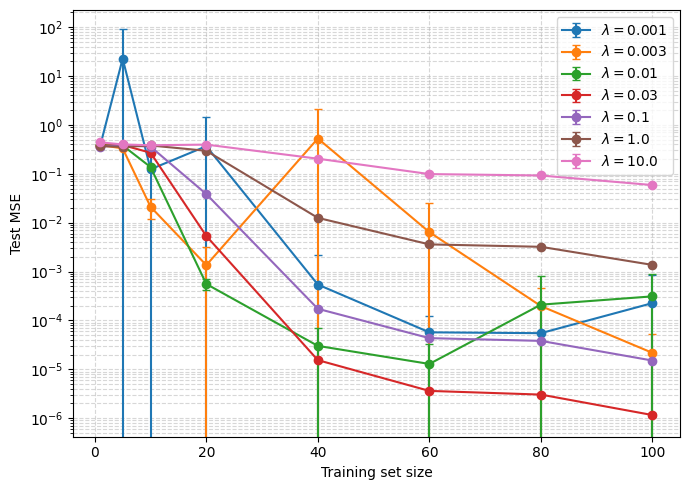

In [2]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    plt.errorbar(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        yerr=res["test_std"][:, li],
        marker="o",
        capsize=3,
        label=rf"$\lambda={lam}$"
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

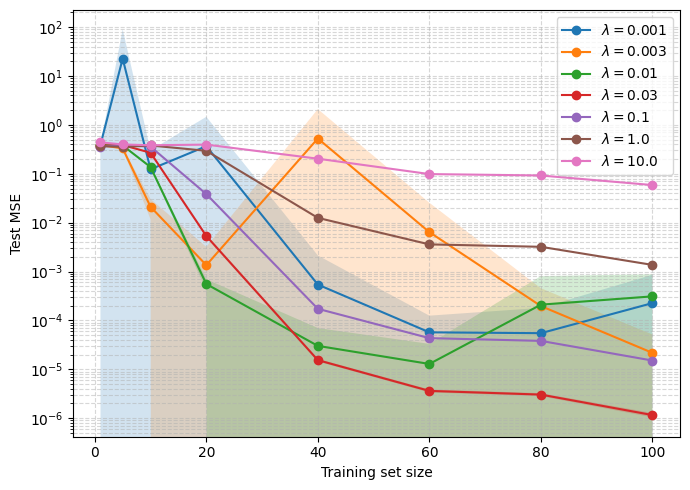

In [3]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    mean = res["test_mean"][:, li]
    std  = res["test_std"][:, li]

    plt.plot(
        TRAIN_SIZES,
        mean,
        marker="o",
        label=rf"$\lambda={lam}$"
    )
    plt.fill_between(
        TRAIN_SIZES,
        mean - std,
        mean + std,
        alpha=0.2
    )

# plt.xscale("log")   # turn on if train sizes span decades
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [4]:
for li, lam in enumerate(LAMBDAS):
    print(f"Lambda = {lam}")
    print(f"Train MSE = {res['train_mean'][:, li]}")
    print(f"Test MSE = {res['test_mean'][:, li]}")

Lambda = 0.001
Train MSE = [3.06695669e-06 9.64539486e-02 1.62320635e-04 4.59895168e-03
 8.13184633e-06 8.43892543e-07 7.66590695e-07 2.68500679e-06]
Test MSE = [3.87072529e-01 2.26803938e+01 1.23557294e-01 3.66655407e-01
 5.41795771e-04 5.70807250e-05 5.48654793e-05 2.26068388e-04]
Lambda = 0.003
Train MSE = [2.73835909e-05 1.96564862e-04 2.39353131e-04 2.22116043e-04
 1.26838024e-01 8.97486802e-04 2.00483789e-05 1.87249815e-06]
Test MSE = [3.86228823e-01 3.31294503e-01 2.10962427e-02 1.35206348e-03
 5.26987113e-01 6.40735646e-03 1.96900087e-04 2.17196439e-05]
Lambda = 0.01
Train MSE = [2.95968937e-04 4.86091772e-05 2.82123066e-04 2.86811417e-05
 8.89938150e-05 2.22618328e-05 1.96891590e-04 2.18261415e-04]
Test MSE = [3.83395912e-01 3.79650574e-01 1.37295973e-01 5.56122421e-04
 3.01537534e-05 1.28766123e-05 2.10312409e-04 3.10595903e-04]
Lambda = 0.03
Train MSE = [2.46651851e-03 1.43898991e-04 5.44734056e-04 2.06500948e-04
 1.09699534e-05 4.02862974e-06 2.86804976e-06 1.48559754e-06]


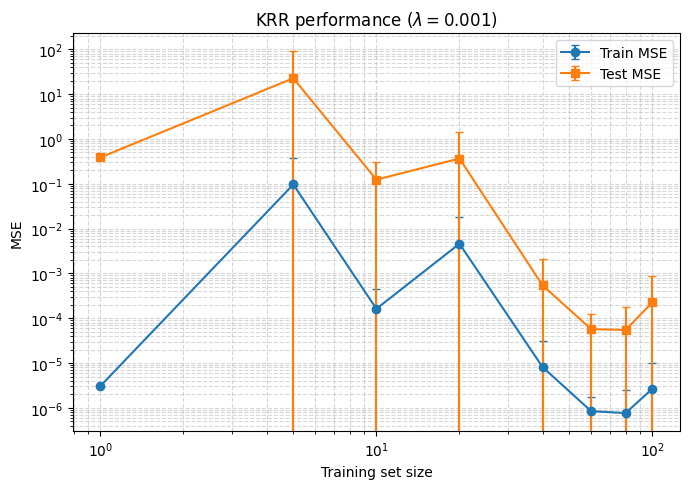

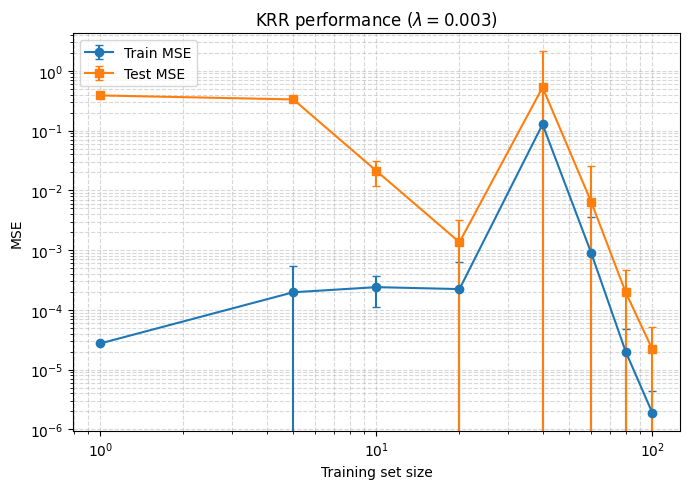

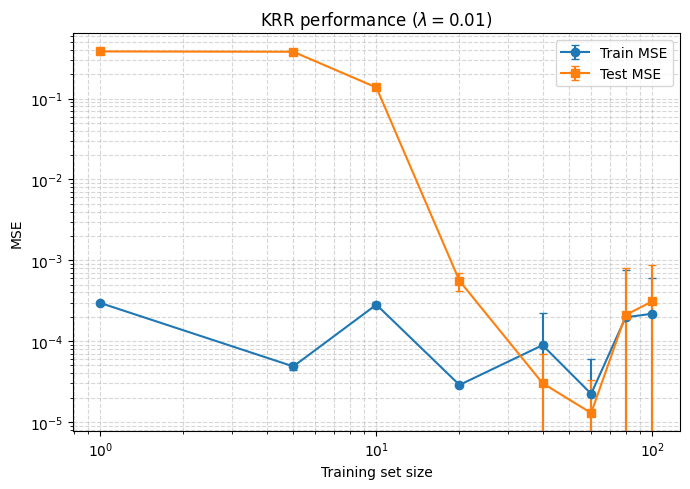

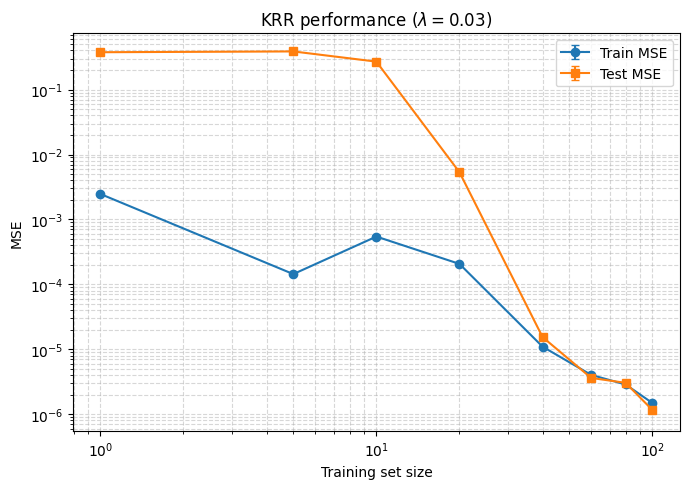

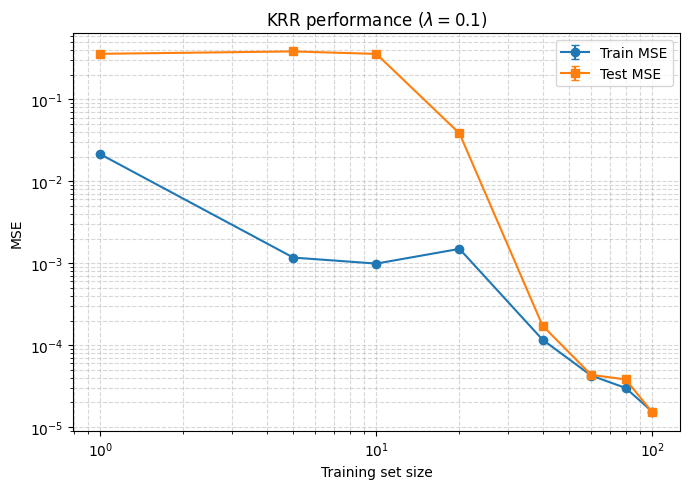

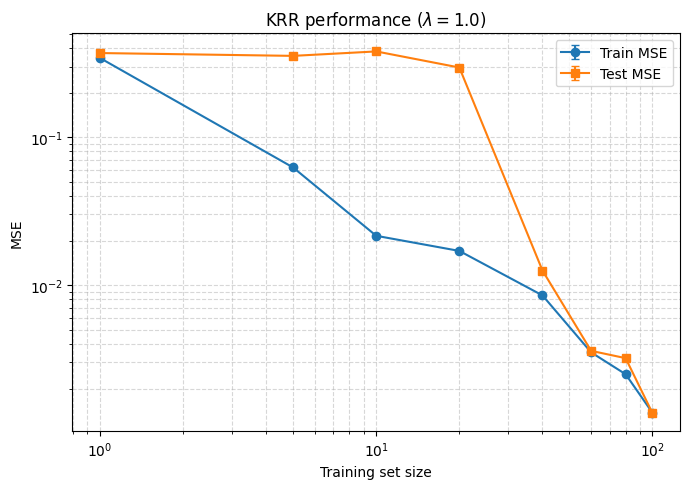

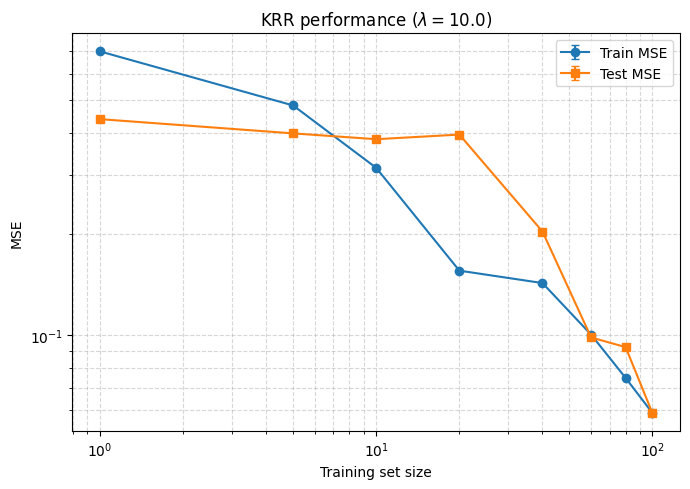

In [5]:
for li, lam in enumerate(LAMBDAS):
    plt.figure(figsize=(7,5))

    # Train
    plt.errorbar(
        TRAIN_SIZES,
        res["train_mean"][:, li],
        yerr=res["train_std"][:, li],
        marker="o",
        capsize=3,
        label="Train MSE"
    )

    # Test
    plt.errorbar(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        yerr=res["test_std"][:, li],
        marker="s",
        capsize=3,
        label="Test MSE"
    )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Training set size")
    plt.ylabel("MSE")
    plt.title(rf"KRR performance ($\lambda={lam}$)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


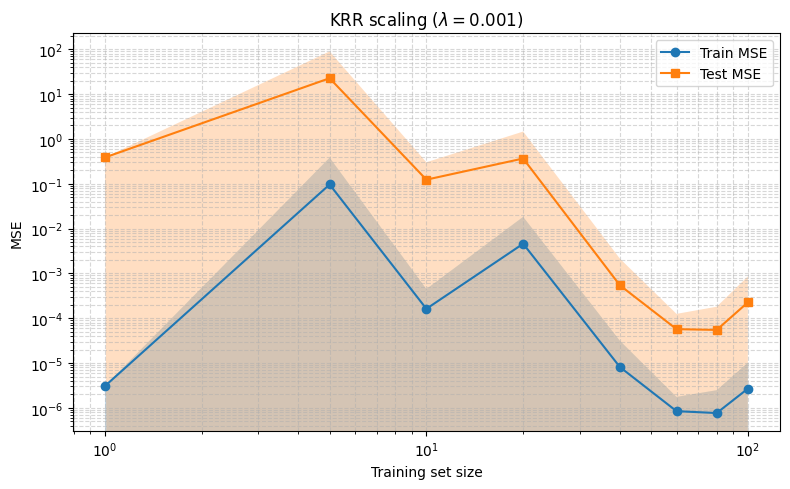

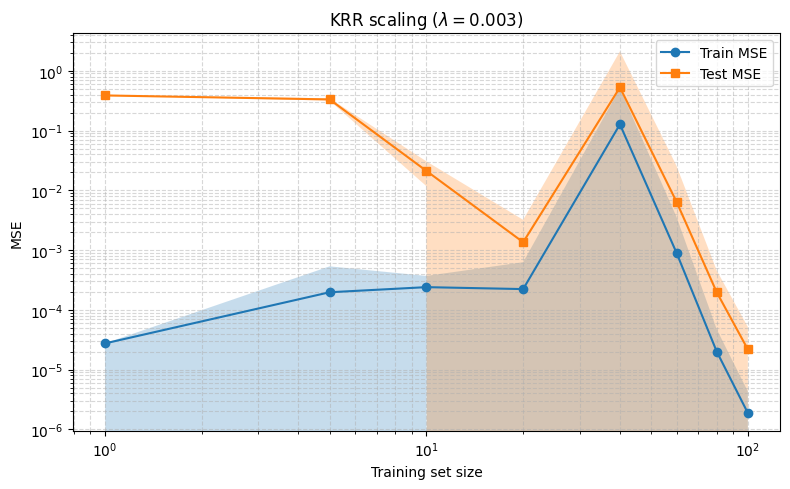

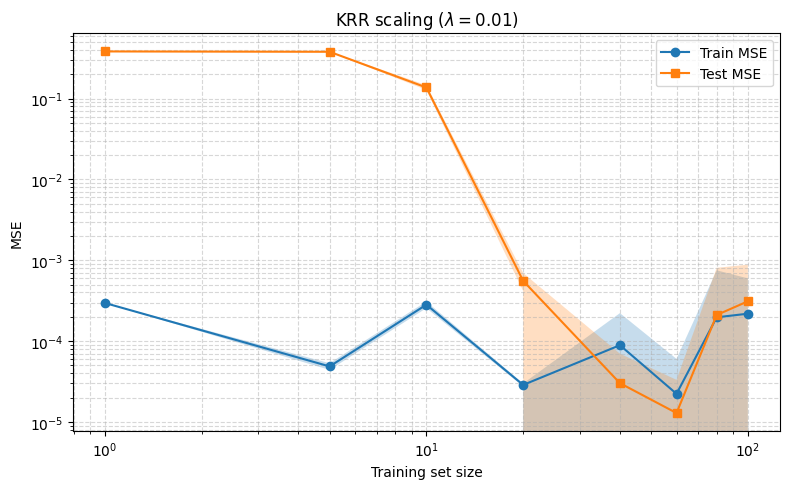

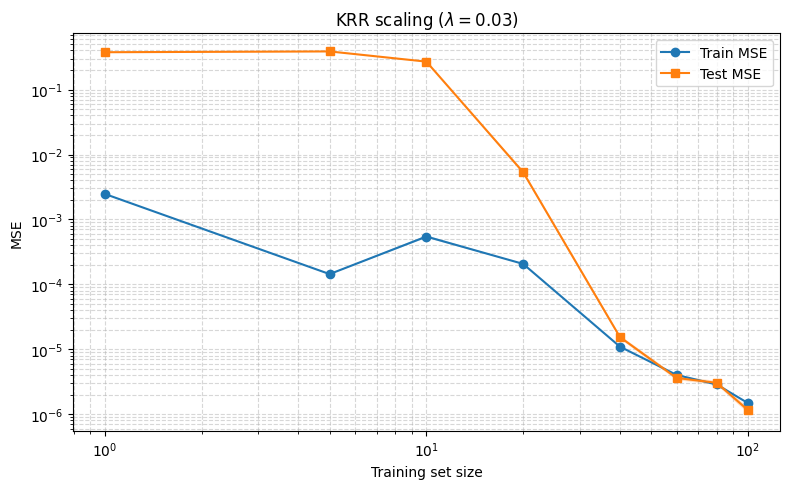

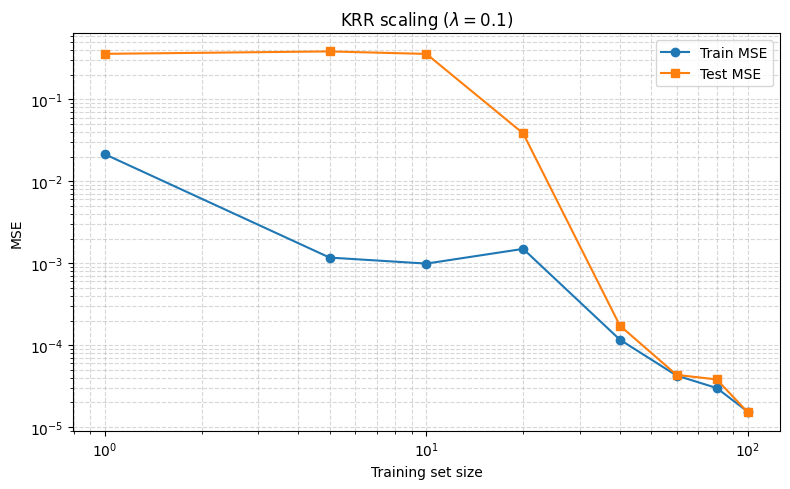

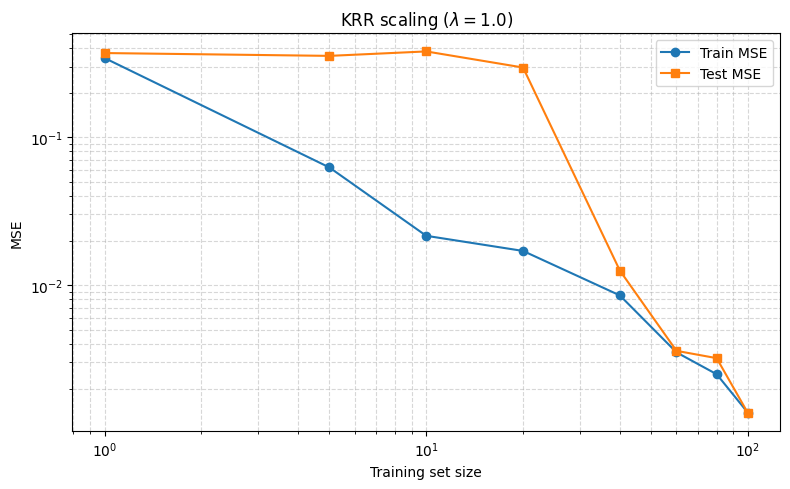

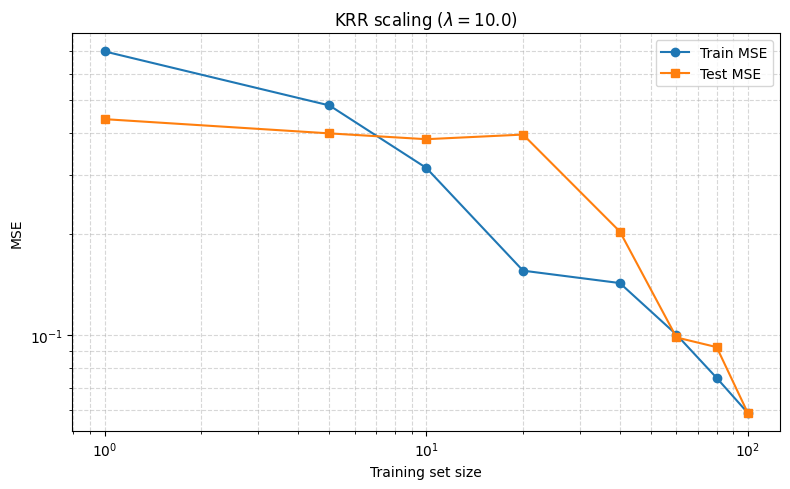

In [6]:
for li, lam in enumerate(LAMBDAS):
    plt.figure(figsize=(8,5))

    # Train MSE
    plt.plot(
        TRAIN_SIZES,
        res["train_mean"][:, li],
        "o-",
        label="Train MSE"
    )
    plt.fill_between(
        TRAIN_SIZES,
        res["train_mean"][:, li] - res["train_std"][:, li],
        res["train_mean"][:, li] + res["train_std"][:, li],
        alpha=0.25
    )

    # Test MSE
    plt.plot(
        TRAIN_SIZES,
        res["test_mean"][:, li],
        "s-",
        label="Test MSE"
    )
    plt.fill_between(
        TRAIN_SIZES,
        res["test_mean"][:, li] - res["test_std"][:, li],
        res["test_mean"][:, li] + res["test_std"][:, li],
        alpha=0.25
    )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Training set size")
    plt.ylabel("MSE")
    plt.title(rf"KRR scaling ($\lambda={lam}$)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


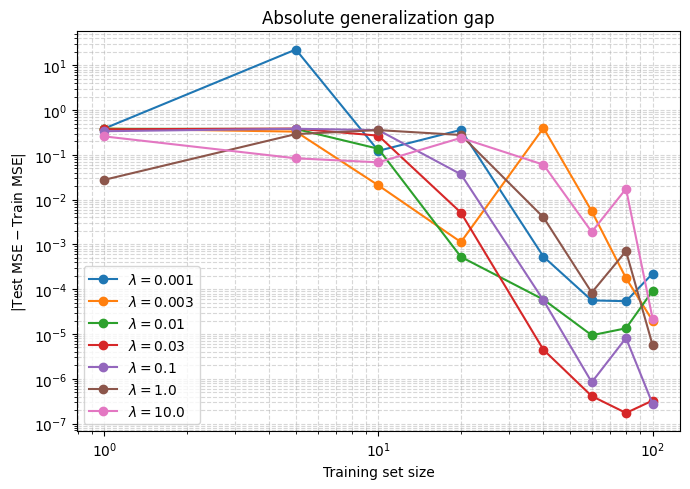

In [7]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    gap_abs = np.abs(
        res["test_mean"][:, li] - res["train_mean"][:, li]
    )

    plt.plot(
        TRAIN_SIZES,
        gap_abs,
        marker="o",
        label=rf"$\lambda={lam}$"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test\ MSE} - \mathrm{Train\ MSE}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


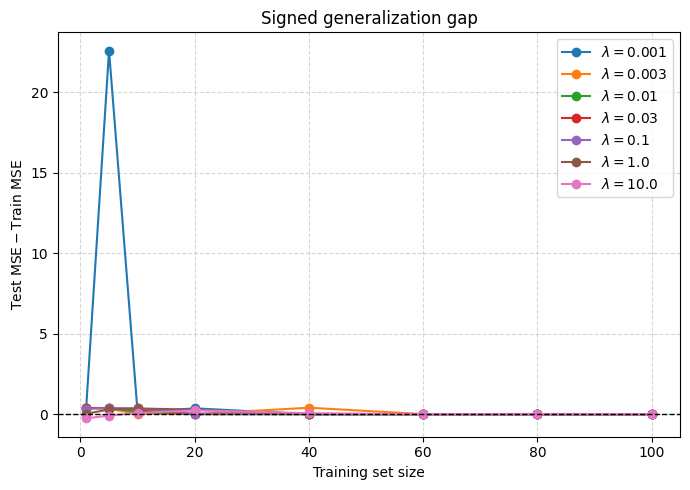

In [8]:
plt.figure(figsize=(7,5))

for li, lam in enumerate(LAMBDAS):
    gap = res["test_mean"][:, li] - res["train_mean"][:, li]

    plt.plot(
        TRAIN_SIZES,
        gap,
        marker="o",
        label=rf"$\lambda={lam}$"
    )

# plt.xscale("log")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Training set size")
plt.ylabel(r"$\mathrm{Test\ MSE} - \mathrm{Train\ MSE}$")
plt.title("Signed generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


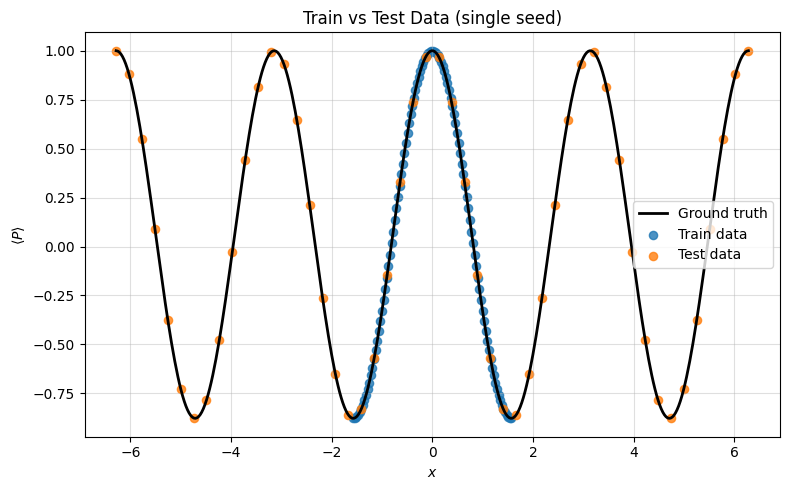

In [9]:
import pennylane as qml
import numpy as np


from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score
import pickle
from pathlib import Path


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    # name = "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α, part = "real"):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    
    if part == "imag":
        qml.adjoint(qml.S)(wires = 0)
        
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α, part="real"):
    AuPAu(x, x1, α, part)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
# x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
# qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0,part = "imag");
# plt.show();


# def conditional_Z_kernel(x, x1, α):
#     samples = AuPAu_sample(x, x1, α)

#     # Extract each register
#     kernel = samples[:, kernel_offset]     # wire 0
#     anc = samples[:, anc_offset]           # anc wire
#     circ = samples[:, circ_offset]         # circ wire

#     # Condition: anc=0 and circ=0
#     mask = (anc == 0) & (circ == 0)
#     conditioned = kernel[mask]

#     total = shots
#     kept = conditioned.shape[0]

#     if kept == 0:
#         return {
#             "total_shots": total,
#             "kept_shots": 0,
#             "expectation": None,
#         }

#     # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
#     zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

#     return {
#         "total_shots": total,
#         "kept_shots": kept,
#         "fraction_kept": kept / total,
#         "expectation": np.mean(zvals),
#     }

def conditional_inner_product(x, x1, α, part="real"):
    samples = AuPAu_sample(x, x1, α, part)

    kernel = samples[:, kernel_offset]
    anc = samples[:, anc_offset]
    circ = samples[:, circ_offset]

    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    if conditioned.size == 0:
        return 0.0

    zvals = 1 - 2 * conditioned
    expectation = np.mean(zvals)
    fraction_kept = conditioned.size / shots

    return fraction_kept * expectation


def complex_kernel(x, x1, α):
    re = conditional_inner_product(x, x1, α, part="real")
    im = conditional_inner_product(x, x1, α, part="imag")
    return re + 1j * im


# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
# X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
# Y = generate_labels(X,alpha)

# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


# if dim_x == 1:
#     plt.plot(X, Y, ".-")
#     plt.xlabel("x")
#     plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
#     plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
# def compute_kernel_matrix_train(X_train, α):
#     n = len(X_train)
#     K = np.zeros((n, n), dtype=complex)

#     for i in tqdm(range(n), desc="Computing train kernel"):
#         for j in range(n):
#             K[i, j] = complex_kernel(X_train[i], X_train[j], α)

#     return K
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n), dtype=complex)

    for i in tqdm(range(n), desc="Computing kernel (upper triangle)"):
        for j in range(i, n):
            val = complex_kernel(X_train[i], X_train[j], α)
            K[i, j] = val
            K[j, i] = np.conj(val)

    # Enforce Hermiticity (shot-noise cleanup)
    K = 0.5 * (K + K.conj().T)
    return K



# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train), dtype=complex)

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            K[i, j] = complex_kernel(X_test[i], X_train[j], α)

    return K


# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
# start_train = time.time()
# K_train = compute_kernel_matrix_train(X_train, alpha)
# end_train = time.time()
# print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

# start_test = time.time()
# K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
# end_test = time.time()
# print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")

def manual_krr_fit(K_train, y_train, lam):
    """
    Manual kernel ridge regression fit.
    Works for real or complex kernels.
    """
    n = K_train.shape[0]
    return np.linalg.solve(K_train + lam * np.eye(n), y_train)


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return (K_test @ coeffs).real

def generate_dataset(num_points, alpha, x_min=-2*np.pi, x_max=2*np.pi):
    """
    Generates X, Y for a single seed.
    X: list of np.array([x])
    Y: np.array of labels
    """
    xs = np.linspace(x_min, x_max, num_points)
    X = [np.array([x]) for x in xs]
    Y = generate_labels(X,alpha)
    return X, Y

# import numpy as np
# import matplotlib.pyplot as plt

# -------------------------------
# Reproduce dataset for one seed
# -------------------------------
SEED = 42
np.random.seed(SEED)

alpha = np.array([0.5])

N_TRAIN_MAX = 100
N_TEST = 50
N_TOTAL = N_TRAIN_MAX + N_TEST

# Generate X (same as in run_single_seed)
# Train data
X_train, Y_train = generate_dataset(
    num_points=N_TRAIN_MAX,
    alpha=alpha,
    x_min=-np.pi/2,
    x_max=np.pi/2
)

# Test data
X_test, Y_test = generate_dataset(
    num_points=N_TEST,
    alpha=alpha,
    x_min=-2*np.pi,
    x_max=2*np.pi
)


# Ground-truth curve
x_dense = np.linspace(-2*np.pi, 2*np.pi, 400)
X_dense = [np.array([x]) for x in x_dense]
Y_dense = np.array([U_return_expval(x, alpha) for x in X_dense])

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(8,5))

plt.plot(x_dense, Y_dense, "k-", lw=2, label="Ground truth")

plt.scatter(
    [x[0] for x in X_train],
    Y_train,
    color="tab:blue",
    s=35,
    label="Train data",
    alpha=0.8
)

plt.scatter(
    [x[0] for x in X_test],
    Y_test,
    color="tab:orange",
    s=35,
    label="Test data",
    alpha=0.8
)

plt.xlabel(r"$x$")
plt.ylabel(r"$\langle P \rangle$")
plt.title("Train vs Test Data (single seed)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
